<a href="https://colab.research.google.com/github/sg16022003-pixel/Cross-Marketing-Analysis/blob/main/Ds_Ecotype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Df_ecotype=pd.read_csv('/content/cover_type (1).csv')
Df_ecotype.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [3]:
Df_ecotype.shape

(145890, 13)

In [4]:
Df_ecotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [5]:
Df_ecotype.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [6]:
Df_ecotype.duplicated().sum()

np.int64(0)

In [7]:
Df_ecotype.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [8]:
if Df_ecotype.duplicated().any():
  Df_ecotype.drop_duplicates(inplace=True)
  print("Duplicates removed")
else:
  print("No duplicates found")

No duplicates found


In [9]:
target_col = 'Hillshade_3pm'

if target_col in Df_ecotype.columns:
    print(f"\n--- Class Distribution ({target_col}) ---")
    print(Df_ecotype[target_col].value_counts())
    print("\n--- Normalized Distribution (%) ---")
    print(Df_ecotype[target_col].value_counts(normalize=True) * 100)
else:
    print(f"\nColumn '{target_col}' not found for distribution check.")


--- Class Distribution (Hillshade_3pm) ---
Hillshade_3pm
138    2402
143    2287
145    2195
129    2181
137    2159
       ... 
248       2
7         2
9         2
1         1
8         1
Name: count, Length: 247, dtype: int64

--- Normalized Distribution (%) ---
Hillshade_3pm
138    1.646446
143    1.567619
145    1.504558
129    1.494962
137    1.479882
         ...   
248    0.001371
7      0.001371
9      0.001371
1      0.000685
8      0.000685
Name: proportion, Length: 247, dtype: float64


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Df_ecotype['Cover_Type'] = le.fit_transform(Df_ecotype['Cover_Type'])
print(Df_ecotype.head())

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

In [11]:
Df_ecotype=pd.get_dummies( Df_ecotype,columns=['Cover_Type'])
Df_ecotype.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type_0,Cover_Type_1,Cover_Type_2,Cover_Type_3,Cover_Type_4,Cover_Type_5,Cover_Type_6
0,2596,51,3,258,0,510,221,232,148,6279,1,29,True,False,False,False,False,False,False
1,2590,56,2,212,-6,390,220,235,151,6225,1,29,True,False,False,False,False,False,False
2,2804,139,9,268,65,3180,234,238,135,6121,1,12,False,False,False,False,True,False,False
3,2785,155,18,242,118,3090,238,238,122,6211,1,30,False,False,False,False,True,False,False
4,2595,45,2,153,-1,391,220,234,150,6172,1,29,True,False,False,False,False,False,False


In [12]:
import pandas as pd
import numpy as np
from scipy import stats

# Load dataset
Df_ecotype = pd.read_csv("/content/cover_type (1).csv")

# -----------------------------
# 1. Handle Missing Values
# -----------------------------

# Numerical columns
num_cols = Df_ecotype.select_dtypes(include=['int64','float64']).columns

# Fill with median
Df_ecotype[num_cols] = Df_ecotype[num_cols].fillna(Df_ecotype[num_cols].median())

# Categorical columns
cat_cols = Df_ecotype.select_dtypes(include=['object']).columns

# Fill with mode
for col in cat_cols:
    Df_ecotype[col] = Df_ecotype[col].fillna(Df_ecotype[col].mode()[0])


# -----------------------------
# 2. Detect and Handle Outliers
# -----------------------------

# Using Z-score
z_scores = np.abs(stats.zscore(Df_ecotype[num_cols]))
Df_ecotype = Df_ecotype[(z_scores < 3).all(axis=1)]

# OR using IQR method
Q1 = Df_ecotype[num_cols].quantile(0.25)
Q3 = Df_ecotype[num_cols].quantile(0.75)
IQR = Q3 - Q1

Df_ecotype = Df_ecotype[~((Df_ecotype[num_cols] < (Q1 - 1.5 * IQR)) | (Df_ecotype[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


# -----------------------------
# 3. Fix Skewness
# -----------------------------

skewness = Df_ecotype[num_cols].skew()

# Apply log transformation if skewness > 1
for col in skewness[skewness > 1].index:
    Df_ecotype[col] = np.log1p(Df_ecotype[col])


print("Data preprocessing completed")
print(Df_ecotype.head())

Data preprocessing completed
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
4       2595      45      2                               153   
5       2579     132      6                               300   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
4                              -1                              391   
5                             -15                               67   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2     

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import joblib

# Load dataset
Df_ecotype = pd.read_csv("/content/cover_type (1).csv")

# -----------------------------
# 1. Feature Transformation
# -----------------------------

# Example: log transform skewed feature
Df_ecotype["Slope"] = np.log1p(Df_ecotype["Aspect"])

# -----------------------------
# 2. Create Interaction / Derived Features
# -----------------------------

# Example interaction term
Df_ecotype["Horizontal_Distance_To_Hydrology "] = Df_ecotype["Vertical_Distance_To_Hydrology"] * Df_ecotype["Horizontal_Distance_To_Roadways"]

# Example derived feature (ratio)
# Df_ecotype[""] = Df_ecotype[""] / (Df_ecotype["distance_work"] + 1) # This line was commented out as it contains undefined columns and is generic placeholder

# Example difference feature
# Df_ecotype[""] = Df_ecotype["shade_index_1"] - Df_ecotype["shade_index_2"] # This line was commented out as it contains undefined columns and is generic placeholder

# -----------------------------
# 3. Encode Categorical Variables
# -----------------------------

categorical_cols = Df_ecotype.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False) # Changed sparse to sparse_output for newer sklearn versions

encoded_features = encoder.fit_transform(Df_ecotype[categorical_cols])

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(categorical_cols)
)

# Drop original categorical columns
Df_ecotype = Df_ecotype.drop(columns=categorical_cols)

# Combine encoded columns with dataset
Df_ecotype = pd.concat([Df_ecotype.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# -----------------------------
# 4. Save Encoder for Inference
# -----------------------------

joblib.dump(encoder, "categorical_encoder.pkl")

print("Feature engineering completed")
print(Df_ecotype.head())

Feature engineering completed
   Elevation  Aspect     Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51  3.951244                               258   
1       2590      56  4.043051                               212   
2       2804     139  4.941642                               268   
3       2785     155  5.049856                               242   
4       2595      45  3.828641                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235      

<Axes: xlabel='Aspect', ylabel='Count'>

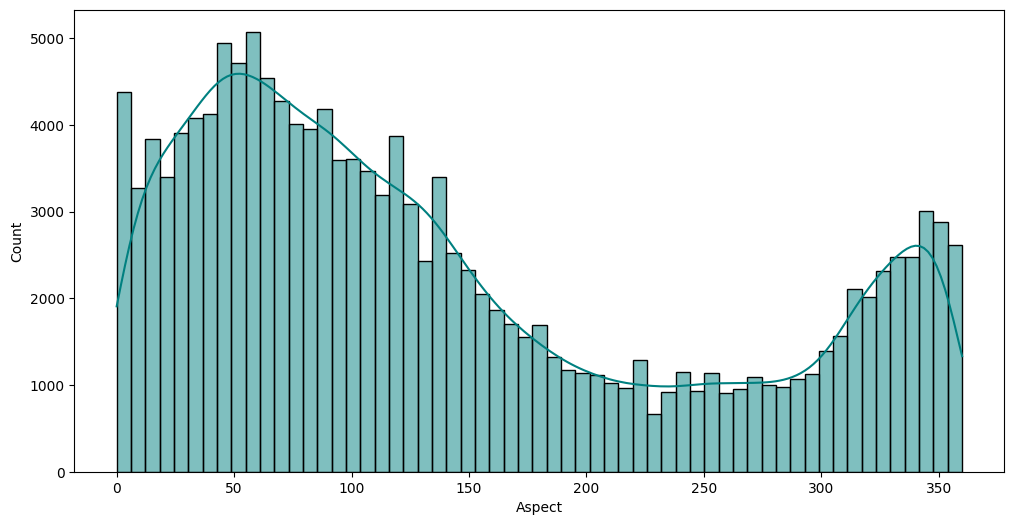

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Aspect'],kde=True,color='teal')

<Axes: xlabel='Slope', ylabel='Count'>

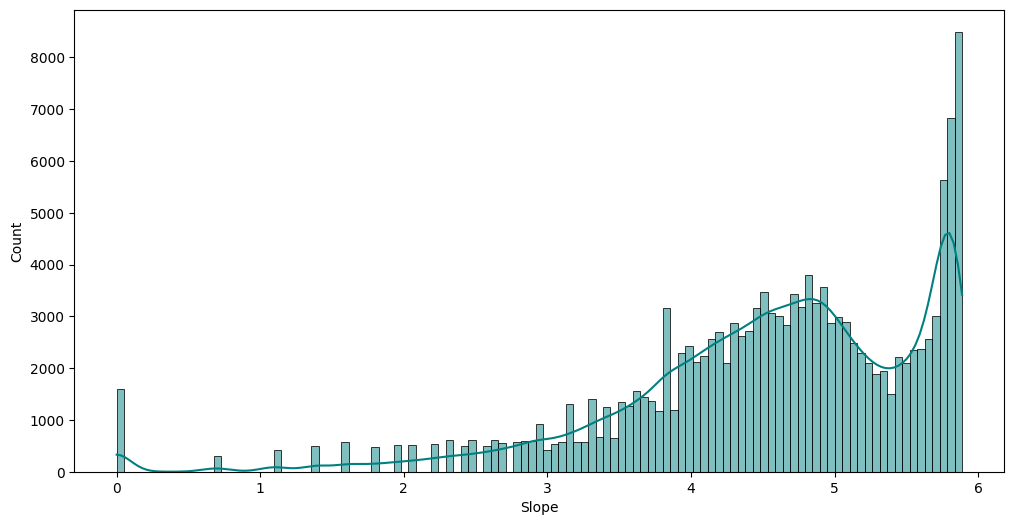

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Slope'],kde=True,color='teal')

<Axes: xlabel='Horizontal_Distance_To_Hydrology', ylabel='Count'>

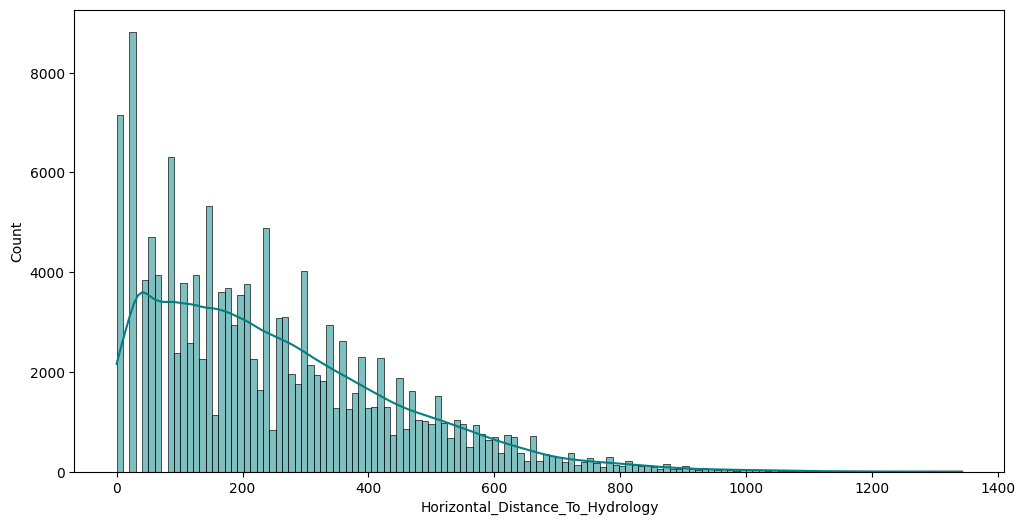

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Horizontal_Distance_To_Hydrology'],kde=True,color='teal')

<Axes: xlabel='Horizontal_Distance_To_Roadways', ylabel='Count'>

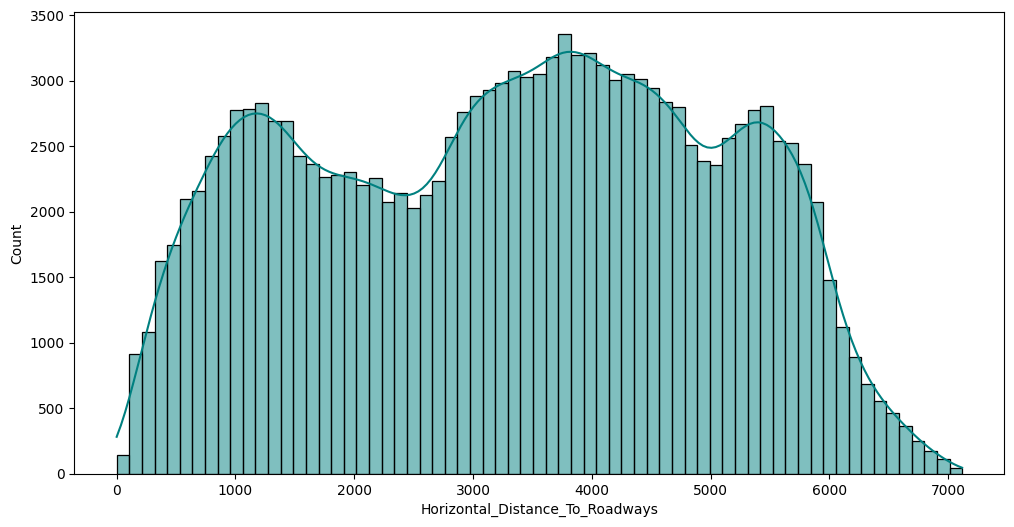

In [17]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Horizontal_Distance_To_Roadways'],kde=True,color='teal')

<Axes: xlabel='Hillshade_9am', ylabel='Count'>

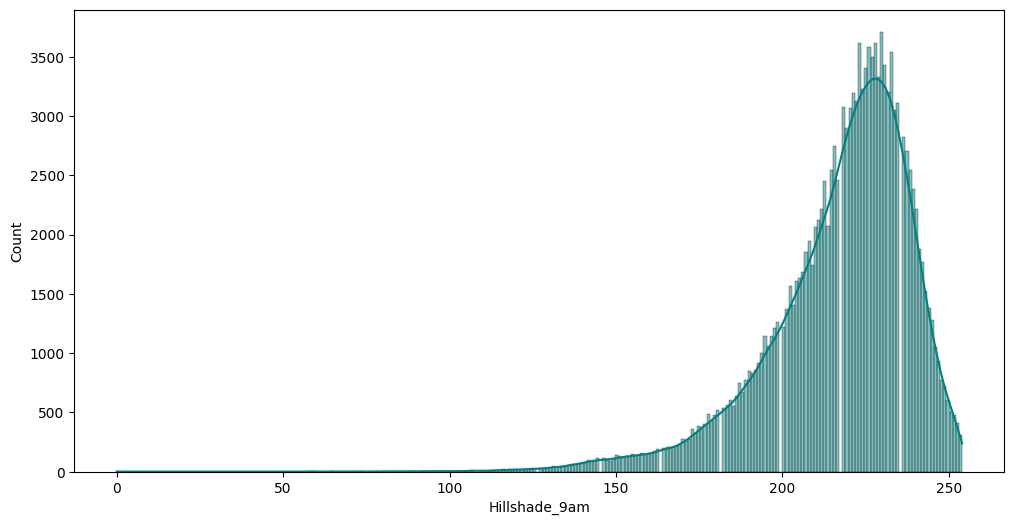

In [18]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Hillshade_9am'],kde=True,color='teal')

<Axes: xlabel='Hillshade_3pm', ylabel='Count'>

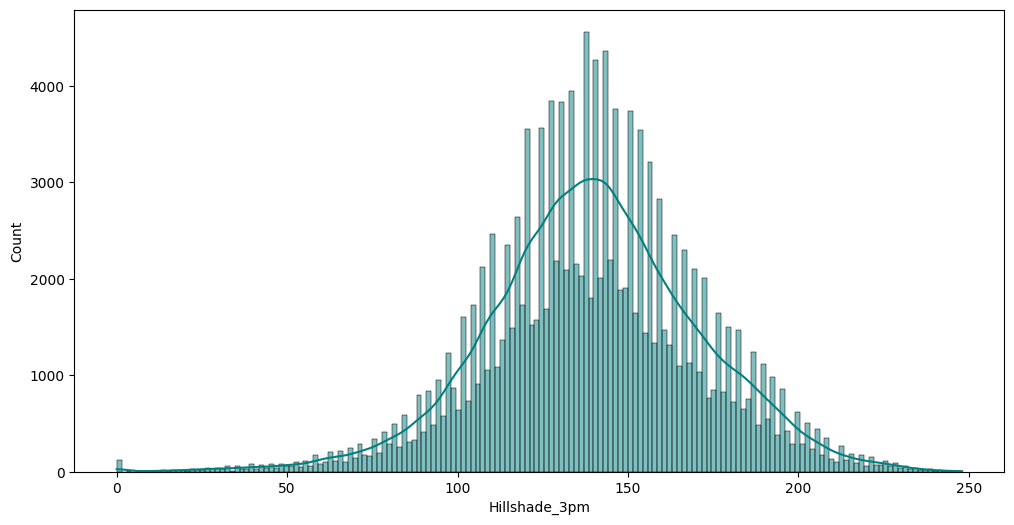

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Hillshade_3pm'],kde=True,color='teal')

<Axes: xlabel='Hillshade_9am', ylabel='Count'>

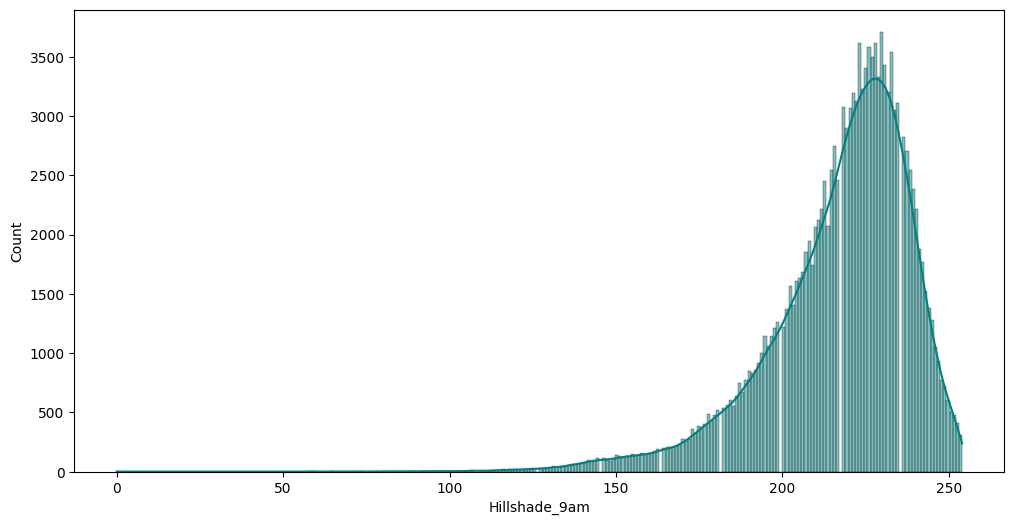

In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Hillshade_9am'],kde=True,color='teal')


<Axes: xlabel='Hillshade_Noon', ylabel='Count'>

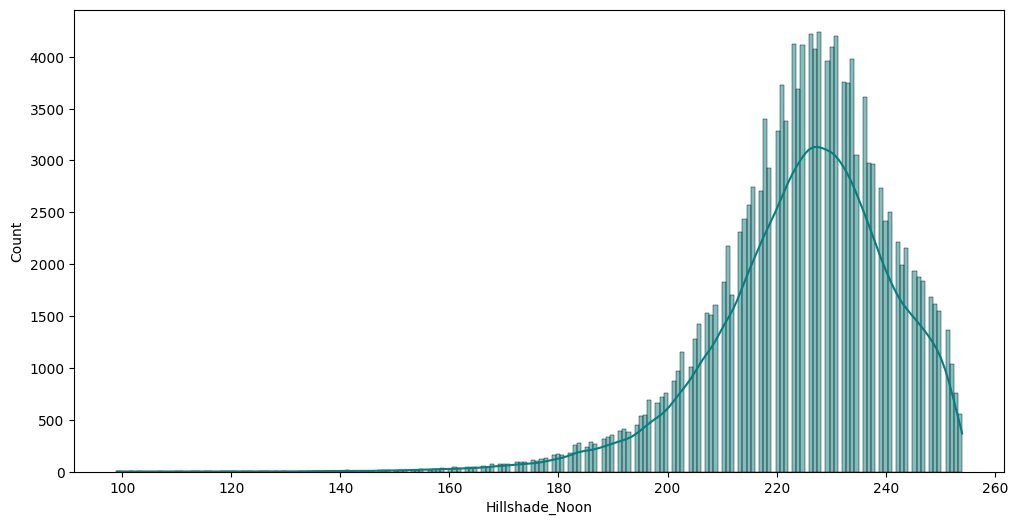

In [21]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Hillshade_Noon'],kde=True,color='teal')


<Axes: xlabel='Horizontal_Distance_To_Fire_Points', ylabel='Count'>

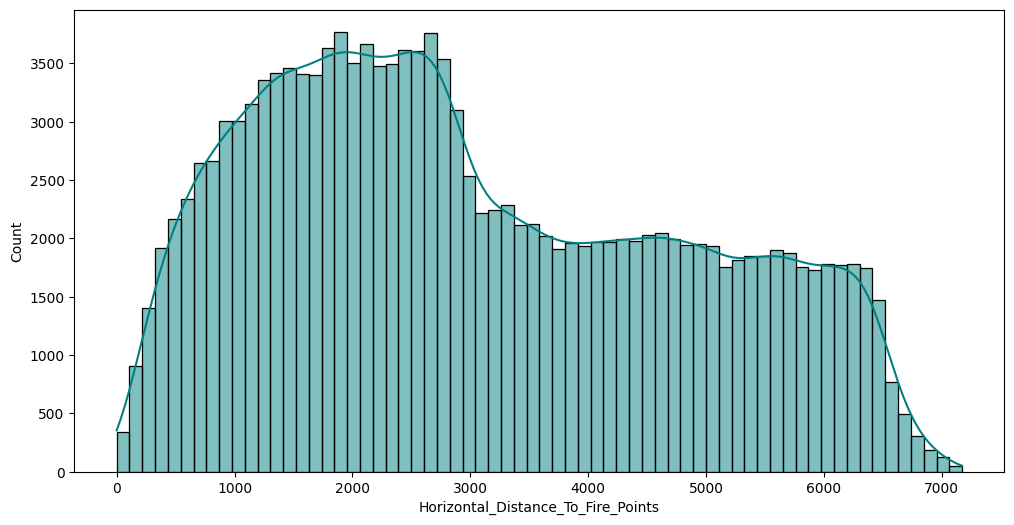

In [22]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Horizontal_Distance_To_Fire_Points'],kde=True,color='teal')

<Axes: xlabel='Aspect', ylabel='Count'>

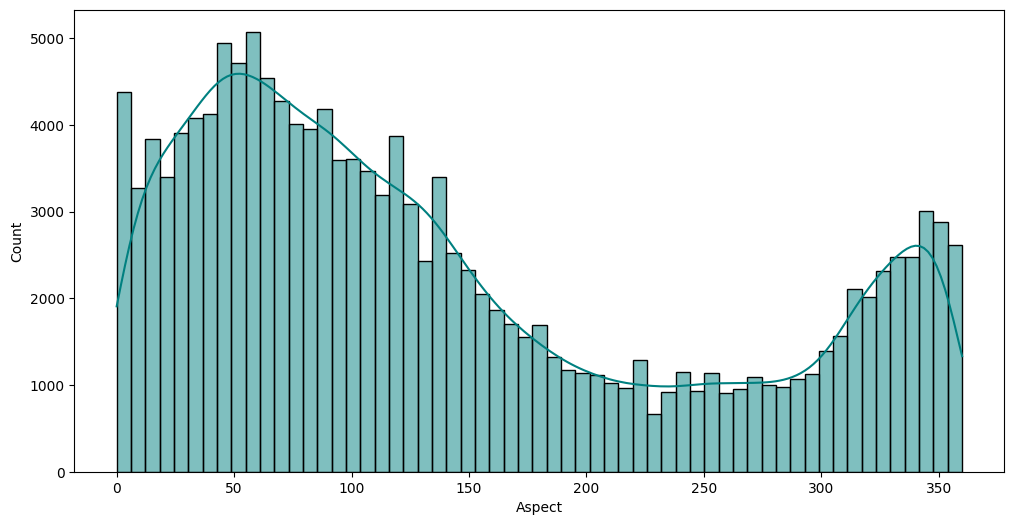

In [23]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Aspect'],kde=True,color='teal')

<Axes: xlabel='Vertical_Distance_To_Hydrology', ylabel='Count'>

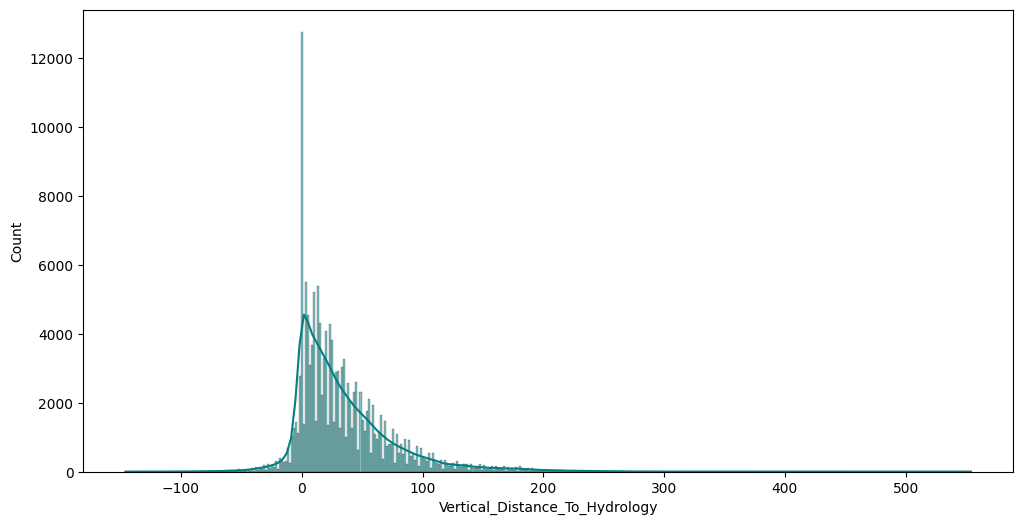

In [24]:
plt.figure(figsize=(12, 6))
sns.histplot(Df_ecotype['Vertical_Distance_To_Hydrology'],kde=True,color='teal')

<Axes: ylabel='Slope'>

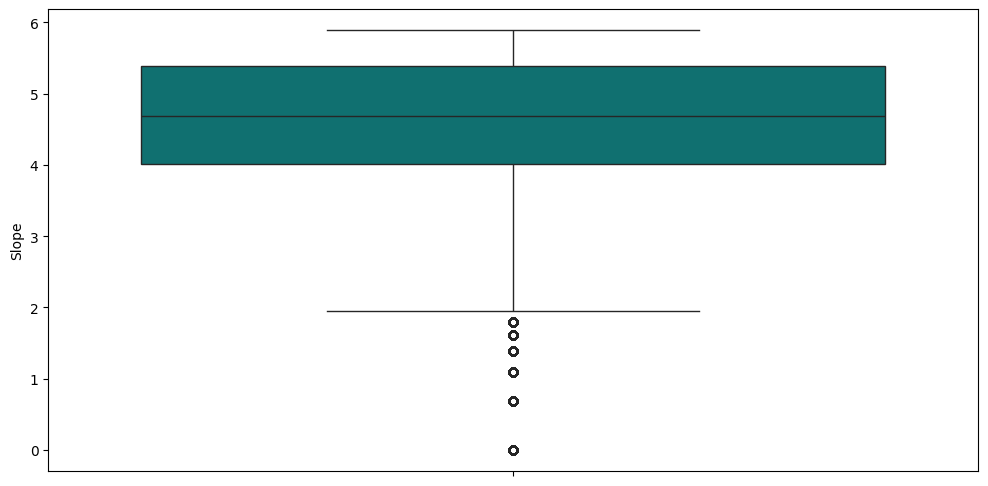

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(Df_ecotype['Slope'],color='teal')

<Axes: ylabel='Horizontal_Distance_To_Hydrology'>

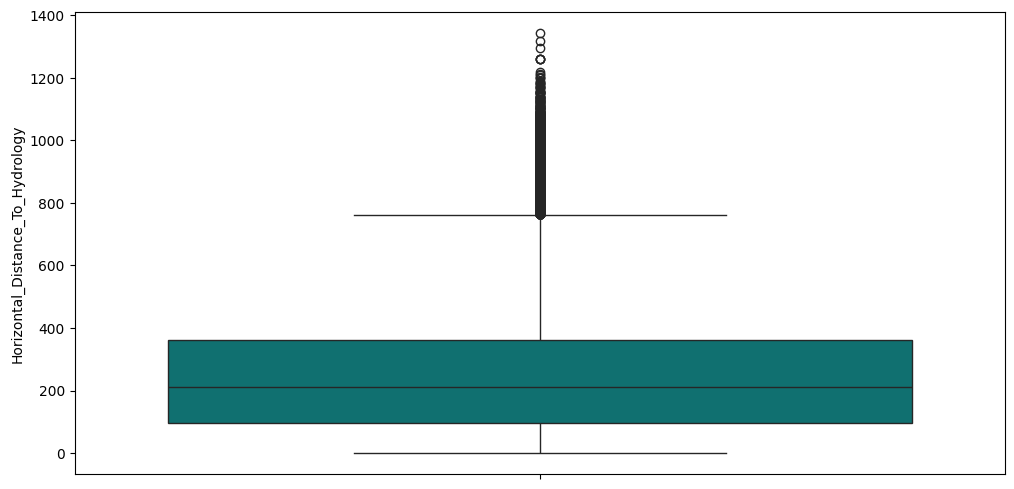

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(Df_ecotype['Horizontal_Distance_To_Hydrology'],color='teal')

<Axes: ylabel='Horizontal_Distance_To_Roadways'>

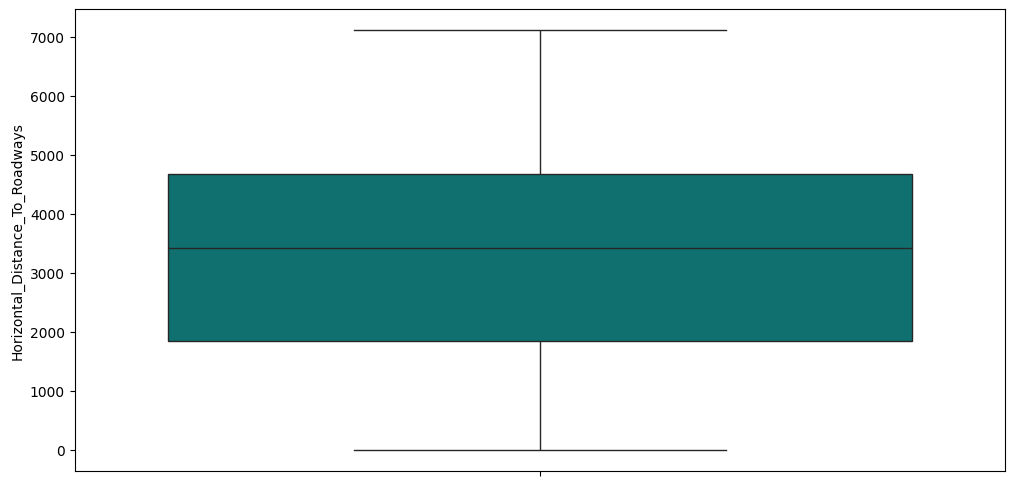

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(Df_ecotype['Horizontal_Distance_To_Roadways'],color='teal')

<Axes: ylabel='Hillshade_9am'>

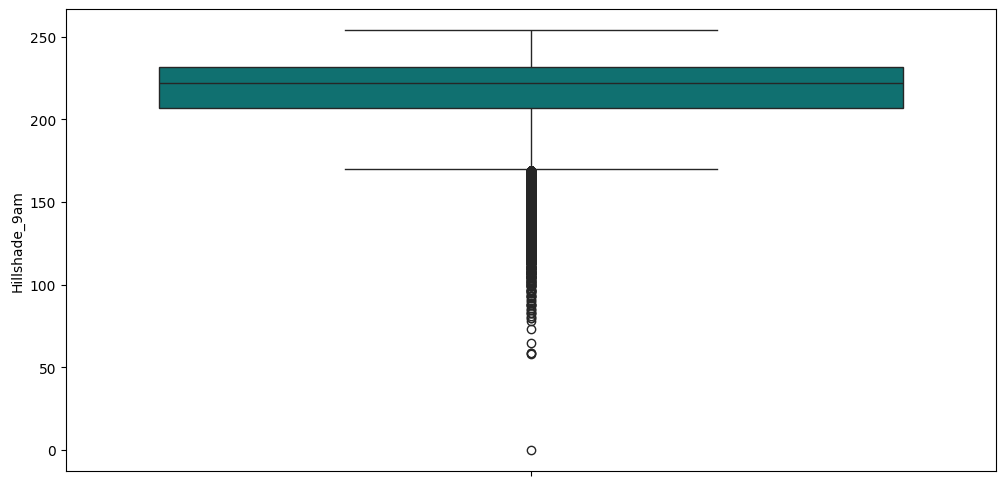

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(Df_ecotype['Hillshade_9am'],color='teal')

<Axes: ylabel='Hillshade_Noon'>

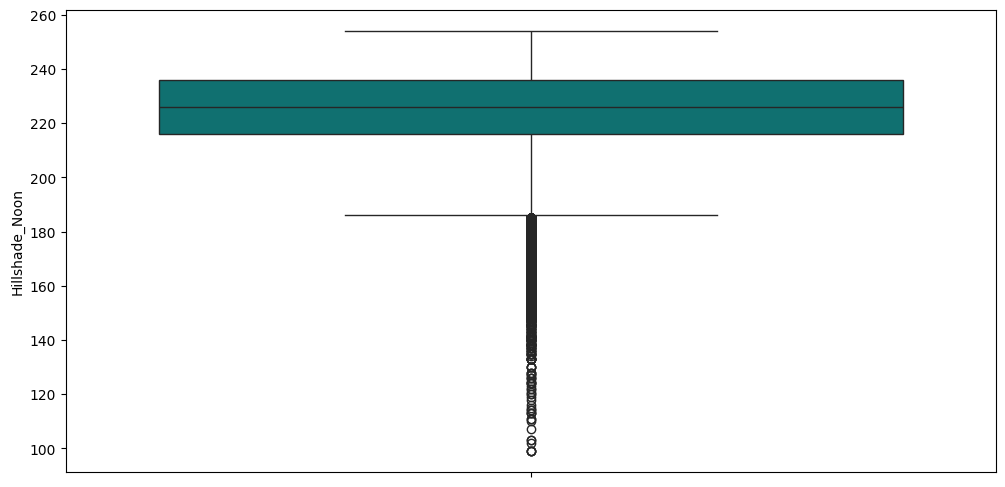

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(Df_ecotype['Hillshade_Noon'],color='teal')


<Axes: ylabel='Horizontal_Distance_To_Fire_Points'>

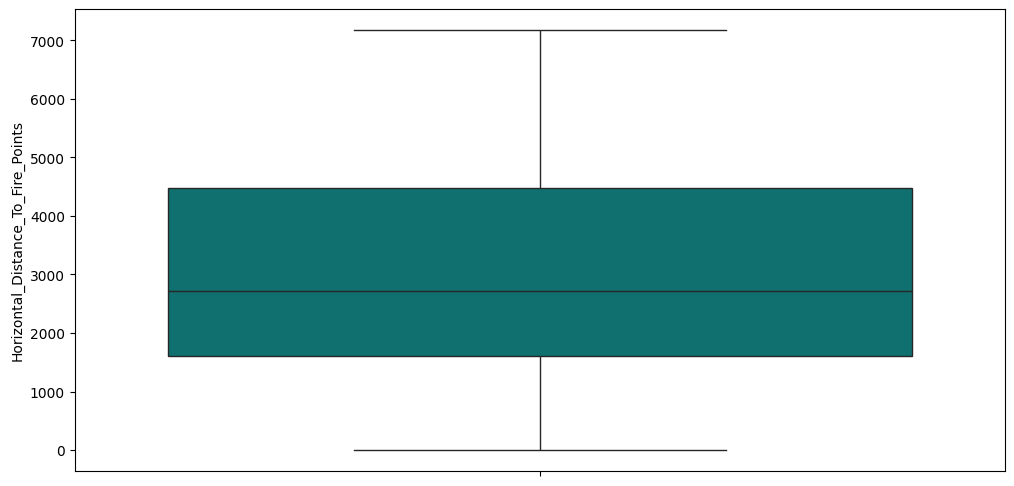

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(Df_ecotype['Horizontal_Distance_To_Fire_Points'],color='teal')

<Axes: ylabel='Aspect'>

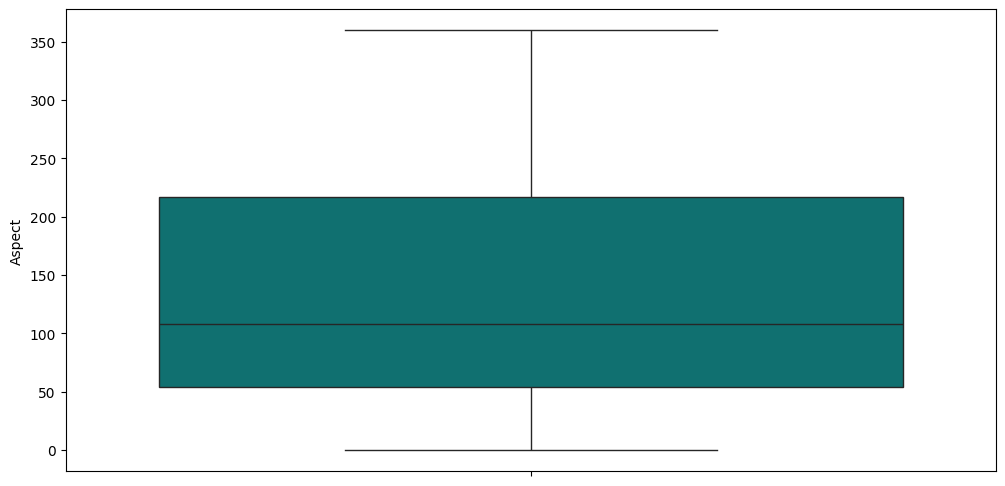

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(Df_ecotype['Aspect'],color='teal')

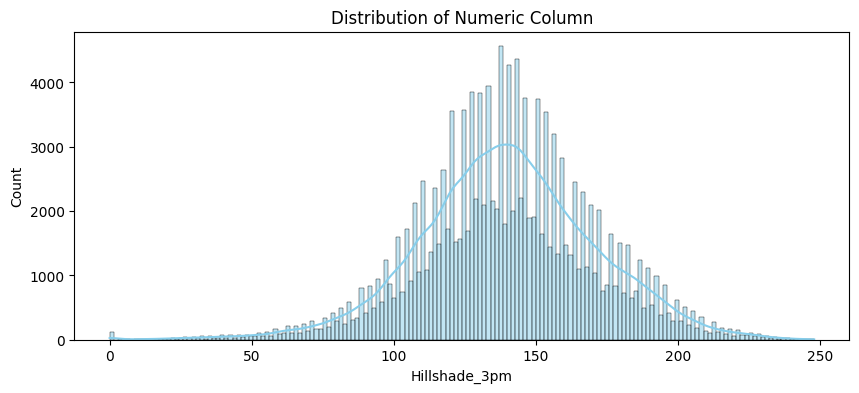

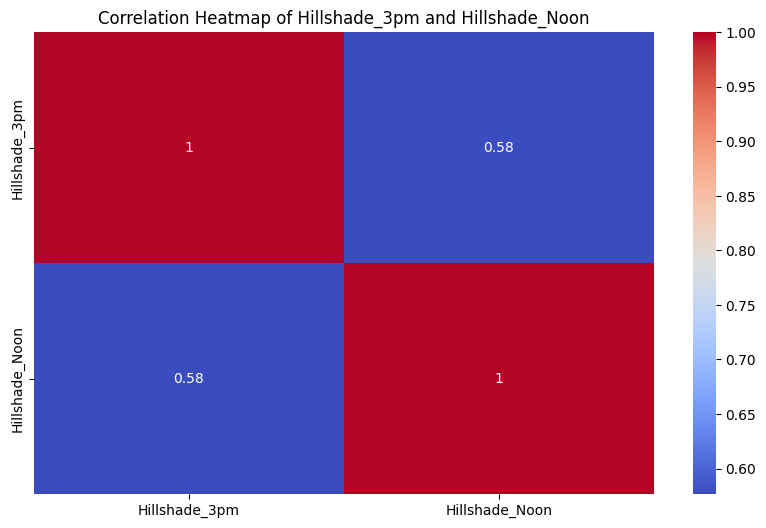

In [32]:

# Load your dataset
# df = pd.read_csv('/content/cover_type (1).csv')

# --- Univariate Analysis: Numerical Distribution ---
plt.figure(figsize=(10, 4))
sns.histplot(Df_ecotype['Hillshade_3pm'], kde=True, color='skyblue')
plt.title('Distribution of Numeric Column')
plt.show()

# --- Bivariate Analysis: Feature vs. Target (Correlation Heatmap) ---
plt.figure(figsize=(10, 6))
# Calculate the correlation matrix for the desired columns
correlation_matrix = Df_ecotype[['Hillshade_3pm', 'Hillshade_Noon']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Hillshade_3pm and Hillshade_Noon')
plt.show()

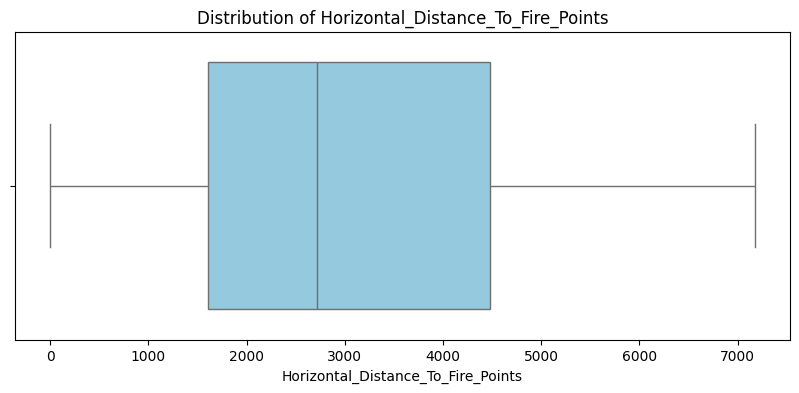

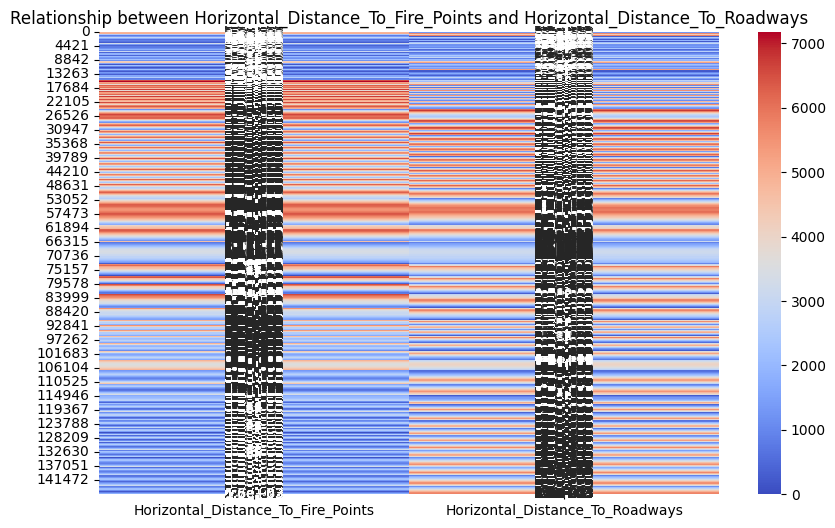

In [33]:
# Load Data
Df_ecotype = pd.read_csv('/content/cover_type (1).csv')

#---Univariate Analysis: Numerical Distribution---
plt.figure(figsize=(10, 4))
sns.boxplot(x='Horizontal_Distance_To_Fire_Points', data=Df_ecotype, color='skyblue')
plt.title('Distribution of Horizontal_Distance_To_Fire_Points')
plt.show()

#---Bivariate Analysis: Feature vs. Target---
plt.figure(figsize=(10,6))
# Calculate the correlation matrix for the desired columns (This line is not necessary for a scatterplot)
correlation_matrix = Df_ecotype[['Horizontal_Distance_To_Fire_Points','Horizontal_Distance_To_Roadways']]
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Relationship between Horizontal_Distance_To_Fire_Points and Horizontal_Distance_To_Roadways')
plt.show()

/tmp/ipykernel_153/688796268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cover_Type', data=Df_ecotype, palette='viridis')


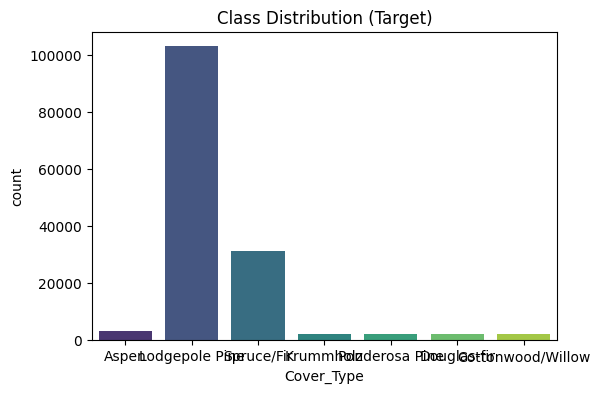

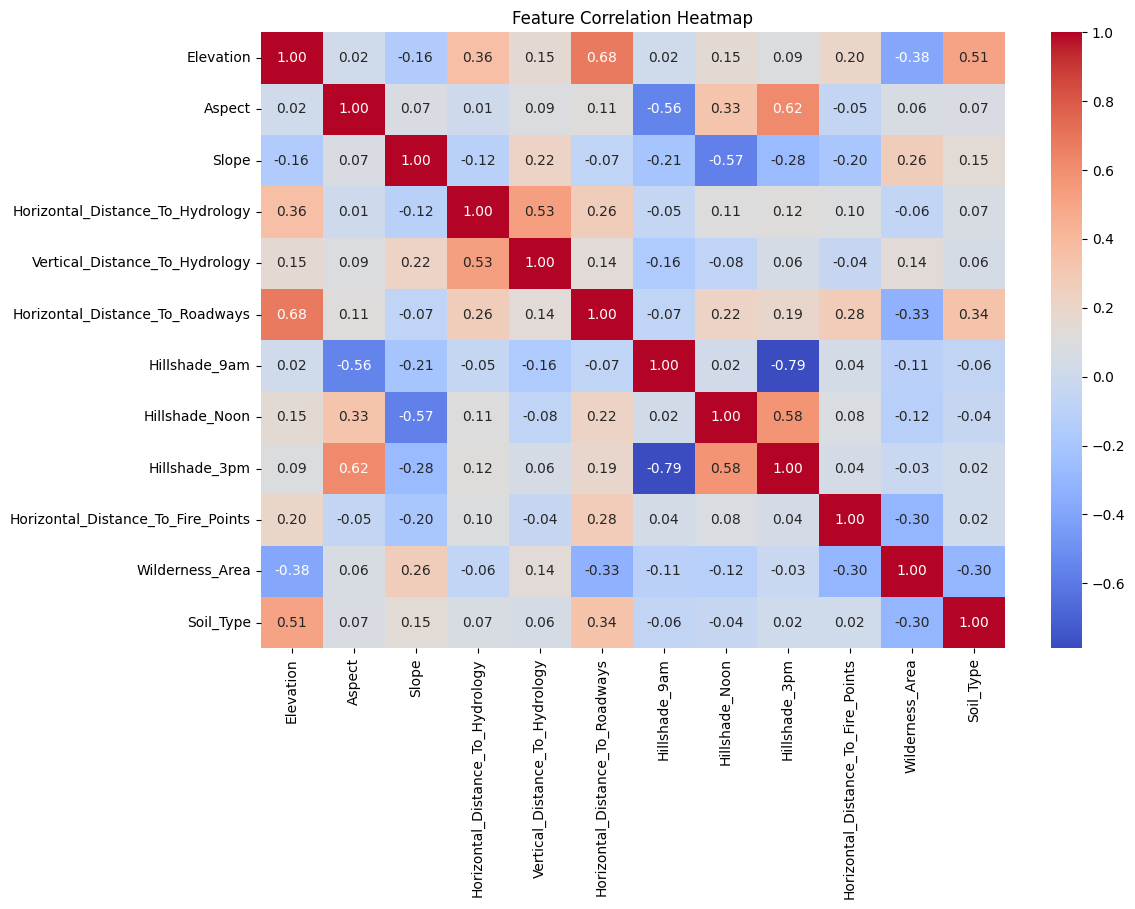

In [34]:
# --- Class Imbalance ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Cover_Type', data=Df_ecotype, palette='viridis')
plt.title('Class Distribution (Target)')
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))
correlation_matrix = Df_ecotype.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [35]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define features (X) and target (y)
X = Df_ecotype.drop('Cover_Type', axis=1)
y = Df_ecotype['Cover_Type']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original dataset shape: {Counter(y_train)}")
print(f"Resampled dataset shape: {Counter(y_train_res)}")

Original dataset shape: Counter({np.int64(4): 71994, np.int64(6): 21885, np.int64(0): 2148, np.int64(1): 1537, np.int64(5): 1521, np.int64(3): 1521, np.int64(2): 1517})
Resampled dataset shape: Counter({np.int64(6): 71994, np.int64(4): 71994, np.int64(1): 71994, np.int64(5): 71994, np.int64(0): 71994, np.int64(3): 71994, np.int64(2): 71994})


/tmp/ipykernel_153/1193035578.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


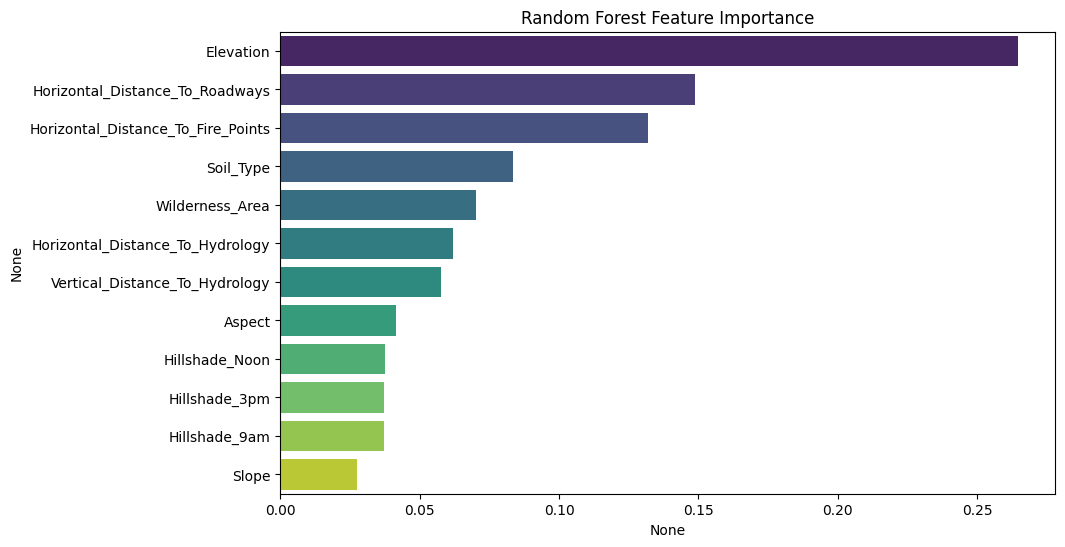

In [36]:
from sklearn.ensemble import RandomForestClassifier
# 1. Fit the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Extract and Sort Importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 3. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title("Random Forest Feature Importance")
plt.show()

In [37]:
from sklearn.model_selection import train_test_split

# The random forest model was already initialized and fitted on X_train earlier
# rf.fit(X_train, y_train) # This line was already executed in a previous cell

# Correctly predict on X_test after training on X_train
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.9531610574176891


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Dt = DecisionTreeClassifier(random_state=42)
Dt.fit(X_train,y_train)
y_pred=Dt.predict(X_test)
accuracy_score(y_test,y_pred)

0.9332830671510499

In [39]:
from sklearn. linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
accuracy_score(y_test,y_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7308931386661183

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.9544177119747755

In [41]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.9362761898233829

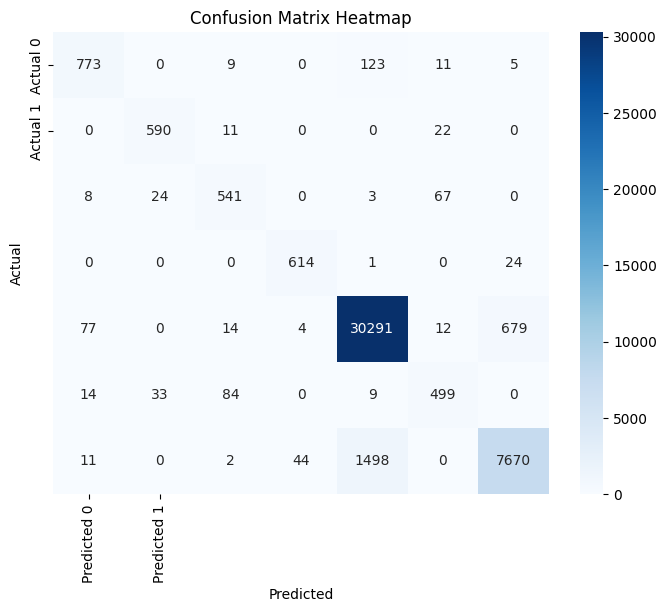

In [42]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [43]:
from sklearn.metrics import classification_report

# Output as a formatted string
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

# OPTIONAL: Convert report to a DataFrame for easier manipulation/plotting
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_Df_ecotype= pd.DataFrame(report_dict).transpose()

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       921
           1       0.91      0.95      0.93       623
           2       0.82      0.84      0.83       643
           3       0.93      0.96      0.94       639
           4       0.95      0.97      0.96     31077
           5       0.82      0.78      0.80       639
           6       0.92      0.83      0.87      9225

    accuracy                           0.94     43767
   macro avg       0.89      0.88      0.88     43767
weighted avg       0.94      0.94      0.94     43767



In [46]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# 1. Load data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the model
rf = RandomForestClassifier()

# 3. Create the parameter distribution
# We use randint for integers and could use uniform for floats
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 11),
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# 4. Set up RandomizedSearchCV
# n_iter=100 means it will try 100 random combinations
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)

# 5. Fit the model
random_search.fit(X_train, y_train)

# 6. Results
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 30, 'min_samples_split': 7, 'n_estimators': 465}
Best Score: 0.9626


In [62]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-03-15 11:40:28--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-15 11:40:29--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-15T12%3A35%3A18Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-15

In [69]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# --- 1. PAGE CONFIGURATION (Must be the first Streamlit command) ---
st.set_page_config(
    page_title="Forest Cover Classifier",
    page_icon="🌲",
    layout="wide"
)

# --- 2. ASSET LOADING ---
@st.cache_resource
def load_assets():
    try:
        model = joblib.load('forest_model.pkl')
        label_encoder = joblib.load('target_encoder.pkl')
        # Load feature names if you saved them to ensure column order matches
        # feature_names = joblib.load('feature_names.pkl')
        return model, label_encoder
    except Exception as e:
        st.error(f"Error loading model files: {e}")
        return None, None

model, le = load_assets()

# --- 3. UI HEADER ---
st.title("🌲 Forest Cover Type Predictor")
st.markdown("""
Enter the cartographic and environmental metrics below to predict the predominant tree cover type.
---
""")

# --- 4. INPUT INTERFACE ---
# Using columns to make the UI cleaner
col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("📍 Location Metrics")
    elevation = st.number_input("Elevation (meters)", min_value=0, value=2500)
    aspect = st.slider("Aspect (0-360°)", 0, 360, 180)
    slope = st.slider("Slope (0-90°)", 0, 90, 15)

with col2:
    st.subheader("💧 Hydrology")
    h_dist_hydro = st.number_input("Horiz. Distance to Water", min_value=0, value=200)
    v_dist_hydro = st.number_input("Vert. Distance to Water", min_value=-500, value=50)

with col3:
    st.subheader("🔥 Safety & Terrain")
    fire_dist = st.number_input("Distance to Fire Points", min_value=0, value=1000)
    road_dist = st.number_input("Distance to Roadways", min_value=0, value=1500)
    wilderness = st.selectbox(
        "Wilderness Area",
        options=["Rawah", "Neota", "Comanche Peak", "Cache la Poudre"]
    )

# --- 5. DATA PREPROCESSING ---
def preprocess_input():
    # Create the base dictionary of numeric features
    data = {
        'Elevation': elevation,
        'Aspect': aspect,
        'Slope': slope,
        'Horizontal_Distance_To_Hydrology': h_dist_hydro,
        'Vertical_Distance_To_Hydrology': v_dist_hydro,
        'Horizontal_Distance_To_Roadways': road_dist,
        'Horizontal_Distance_To_Fire_Points': fire_dist,
    }

    # Handling One-Hot Encoding for Wilderness Area
    # (Assuming your model expects columns like 'Wilderness_Area_0', etc.)
    areas = ["Rawah", "Neota", "Comanche Peak", "Cache la Poudre"]
    for i, area in enumerate(areas):
        data[f'Wilderness_Area_{i}'] = 1 if wilderness == area else 0

    return pd.DataFrame([data])

# --- 6. PREDICTION LOGIC ---
st.markdown("---")
if st.button("🌲 Predict Forest Cover Type", use_container_width=True):
    if model is not None:
        input_df = preprocess_input()

        # Predict
        prediction_idx = model.predict(input_df)

        # Inverse Transform
        try:
            readable_prediction = le.inverse_transform(prediction_idx)[0]

            # Display Result
            st.balloons()
            st.success(f"### Predicted Cover Type: **{readable_prediction}**")

            # Show prediction probabilities (optional)
            probs = model.predict_proba(input_df)
            st.info(f"Confidence Level: {np.max(probs)*100:.2f}%")

        except Exception as e:
            st.error(f"Prediction error: {e}. Check if feature columns match the training set.")
    else:
        st.warning("Model not loaded. Please check your .pkl files.")

# --- 7. FOOTER ---
st.sidebar.info("This model uses Random Forest classification to analyze forest composition based on USGS data.")

2026-03-15 11:43:02.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 11:43:02.927 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 11:43:02.929 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 11:43:02.929 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 11:43:02.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 11:43:02.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 11:43:02.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 11:43:02.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

In [70]:
!streamlit run /content/app.py &>/content/logs.txt &  # here instead of app.py please rename with your file name

In [71]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://genius-attacks-phentermine-traditional.trycloudflare.com
